In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import MultinomialNB


In [2]:
# pltのデフォルト設定
plt.rcParams["figure.figsize"] = (12, 8)
default_plot_colour = "#00bfbf"

In [3]:
# データの読み込む
data = pd.read_csv("fake_news_data.csv")
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [4]:
data["text"][1
]

'Buried in Trump s bonkers interview with New York Times reporters Maggie Haberman and Glenn Thrush is this outrageous exchange Trump claims happened recently:TRUMP: [U.S. Representative] Elijah Cummings was in my office and he said,  You will go down as one of the great presidents in the history of our country. HABERMAN: Really?TRUMP: And then he went out and I watched him on television yesterday and I said,  Was that the same man? Which  would have been odd considering Cummings, a fiery Democratic congressman, has been one of Trump s most intense critics. He s very public about it. Cummings has been outspoken about Trump s disturbing connections to Russia, the GOP s botched attempts to cover those connections up, and has repeatedly demanded Trump divest himself of his numerous conflicts of interest. He hardly sounds like a person who has looked at Trump s trainwreck first three months in office and concluded that he deserves to be up on Mount Rushmore.One theory was that Trump flatly

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0, 0.5, 'counts')

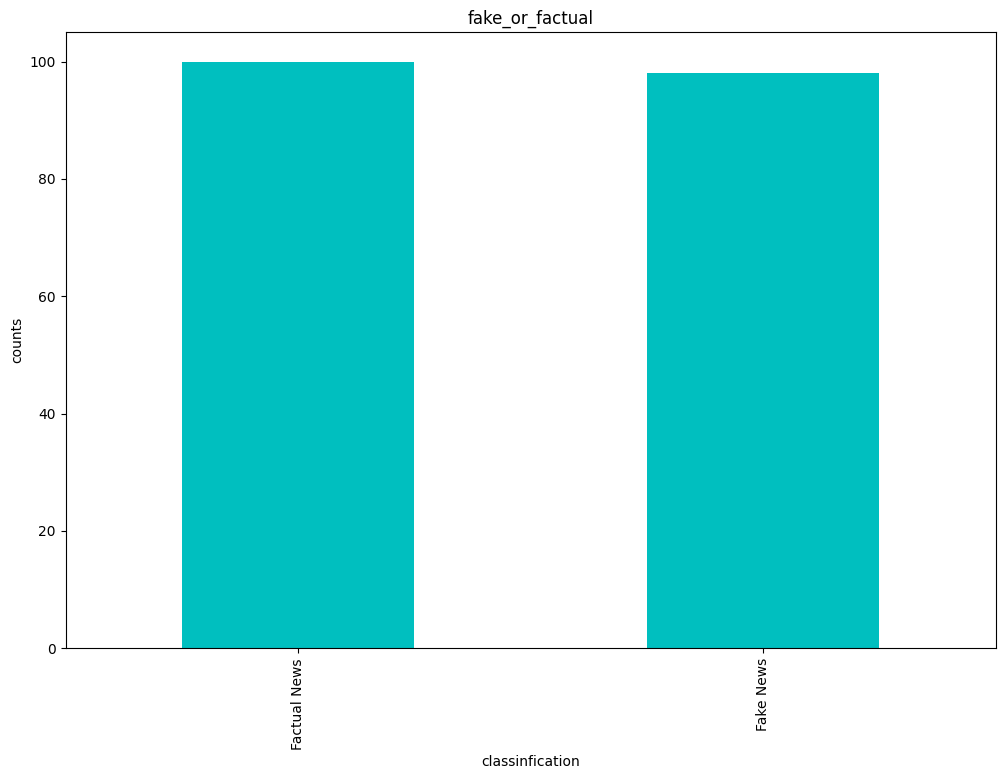

In [6]:
#　データのfakeとfactualの比率
data["fake_or_factual"].value_counts().plot(kind="bar", color=default_plot_colour)
plt.title("fake_or_factual")
plt.xlabel("classinfication")
plt.ylabel("counts")

#### 品詞タグ付け

In [7]:
nlp = spacy.load("en_core_web_sm")

In [8]:
fake_news = data[data["fake_or_factual"] == "Fake News"]
fact_news = data[data["fake_or_factual"] == "Factual News"]

In [9]:
# spacyドキュメントの作成
fake_spacydocs = list(nlp.pipe(fake_news["text"]))
fact_spacydocs = list(nlp.pipe(fact_news["text"]))

In [10]:
# 文章内のトークン・固有表現・品詞の抽出関数
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return [(i.text, i.ent_type_, i.pos_) for i in doc]

In [11]:
# FakeNewsのタグの抽出
columns = ["token", "ner_tag", "pos_tag"]
fake_tagsdf = []


for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)

fake_tagsdf = pd.concat(fake_tagsdf)


# FackNewsのタグの抽出
fact_tagsdf = []

for ix, doc in enumerate(fact_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)

fact_tagsdf = pd.concat(fact_tagsdf)

In [12]:
fake_tagsdf

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN
...,...,...,...
743,.,,PUNCT
744,Via,,PROPN
745,:,,PUNCT
746,Campus,PERSON,PROPN


In [13]:
fact_tagsdf

,token,ner_tag,pos_tag
0,WASHINGTON,GPE,PROPN
1,(,,PUNCT
2,Reuters,ORG,PROPN
3,),,PUNCT
4,-,,PUNCT
...,...,...,...
85,citing,,VERB
86,three,CARDINAL,NUM
87,unnamed,,ADJ
88,officials,,NOUN


In [14]:
# 頻出度の抽出：（トークン、固有表現）の組み
pos_counts_fake = fake_tagsdf.groupby(["token", "pos_tag"]).size().reset_index(name="counts")
pos_counts_fake = pos_counts_fake.sort_values("counts", ascending=False)

pos_counts_fact = fact_tagsdf.groupby(["token", "pos_tag"]).size().reset_index(name="counts")
pos_counts_fact = pos_counts_fact.sort_values("counts", ascending=False)

In [15]:
pos_counts_fake.head()

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875


In [16]:
pos_counts_fact.head()

,token,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789


In [17]:
# 品詞毎の出現回数
pos_counts_fake.groupby("pos_tag")["token"].count().sort_values(ascending=False)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
DET        42
INTJ       24
PUNCT      23
CCONJ      19
X          14
PART       10
SYM         5
SPACE       3
Name: token, dtype: int64

In [18]:
pos_counts_fact.groupby("pos_tag")["token"].count().sort_values(ascending=False)

pos_tag
NOUN     2179
VERB     1539
PROPN    1379
ADJ       747
ADV       263
NUM       205
PRON       79
ADP        70
AUX        43
SCONJ      42
DET        36
PUNCT      22
SPACE      11
CCONJ      11
X          10
INTJ        7
PART        7
SYM         4
Name: token, dtype: int64

In [19]:
# 品詞がNOUN（名詞）のトークンの確認
pos_counts_fake[pos_counts_fake["pos_tag"] == "NOUN"][0:10]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [20]:
pos_counts_fact[pos_counts_fact["pos_tag"] == "NOUN"][0:10]

,token,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
4259,law,NOUN,42


In [21]:
#　固有表現の確認
top_entities_fake = fake_tagsdf[fake_tagsdf["ner_tag"] != ""]
top_entities_fake = top_entities_fake.groupby(["token", "ner_tag"]).size().reset_index(name="counts").sort_values("counts", ascending=False)

top_entities_fact = fact_tagsdf[fact_tagsdf["ner_tag"] != ""]
top_entities_fact = top_entities_fact.groupby(["token", "ner_tag"]).size().reset_index(name="counts").sort_values("counts", ascending=False)

In [22]:
top_entities_fake.head(10)

,token,ner_tag,counts
1730,Trump,PERSON,154
1729,Trump,ORG,152
2129,the,ORG,121
592,Clinton,PERSON,118
718,Donald,PERSON,75
890,Hillary,PERSON,64
1329,Obama,PERSON,59
1179,McCain,PERSON,53
2167,year,DATE,44
1662,Syria,GPE,42


In [23]:
top_entities_fact.head(10)

,token,ner_tag,counts
1968,the,ORG,159
1633,U.S.,GPE,138
1373,Reuters,ORG,131
1615,Trump,PERSON,125
1614,Trump,ORG,124
882,House,ORG,67
1997,year,DATE,63
1646,United,GPE,59
1965,the,GPE,59
1254,Obama,PERSON,55


In [24]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

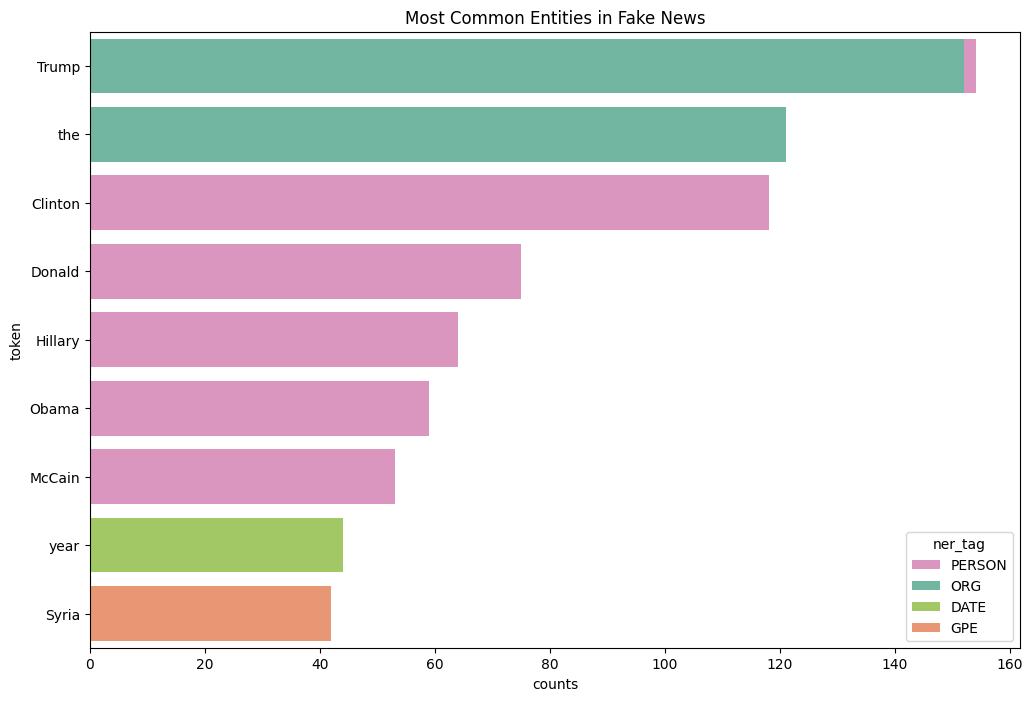

In [25]:

sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most Common Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Entities in FactNews')]

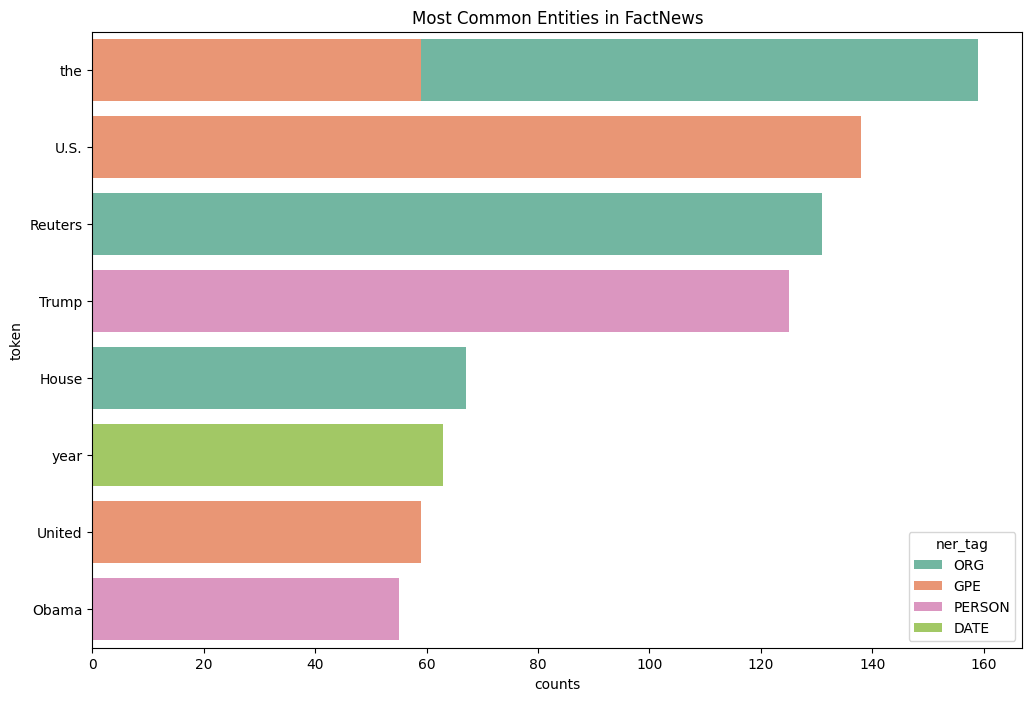

In [26]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[0:10],
    orient = 'h',
    dodge=False
) \
.set(title='Most Common Entities in FactNews')

### Prepocessing

In [27]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [28]:
# -と空白の除去
data["text_clean"] = data.apply(lambda x: re.sub(r"^[^-]*-\s*", "", x["text"]), axis=1)

# 小文字化
data["text_clean"] = data["text_clean"].str.lower()

# 記号等の除去
data["text_clean"] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x["text_clean"]), axis=1)

In [29]:
# stopwordの除去
en_stopwords = stopwords.words("english")
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [30]:
# stopwordの除去
data["text_clean"] = data["text_clean"].apply(lambda x: " ".join([word for word in x.split() if word not in (en_stopwords)]))

In [31]:
# 単語に分割
data["text_clean"] = data.apply(lambda x: word_tokenize(x["text_clean"]), axis=1)

In [32]:
# lemmatize
lemmatizer = WordNetLemmatizer()
data["text_clean"] = data["text_clean"].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [33]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [34]:
# n-gram
tokens_clean = sum(data["text_clean"], [])
unigrams = pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts().reset_index()[:10]
unigrams.columns = ["index", "count"]
print(unigrams)

           index  count
0        (said,)    560
1       (trump,)    520
2           (u,)    255
3       (state,)    250
4   (president,)    226
5       (would,)    210
6         (one,)    141
7        (year,)    128
8  (republican,)    128
9        (also,)    124


/var/folders/_1/45kfssl94hl6vgk_4qg_qq5c0000gn/T/ipykernel_34439/1499214839.py:4: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = "count",


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

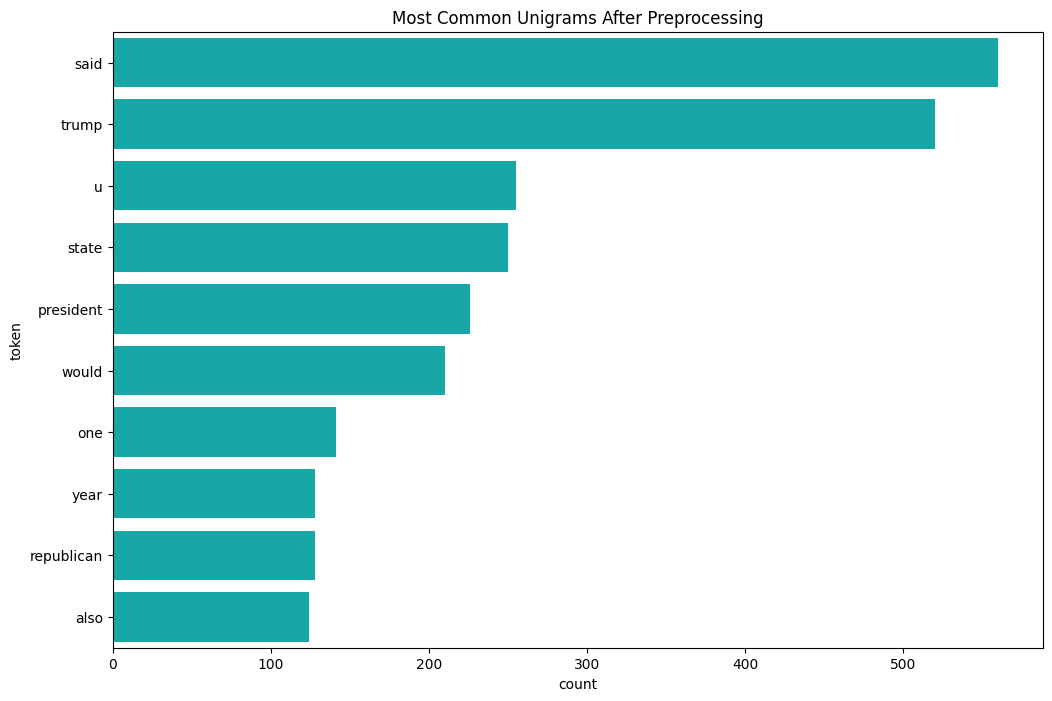

In [35]:
# unigrams可視化
unigrams['token'] = unigrams['index'].apply(lambda x: x[0]) 

sns.barplot(x = "count", 
            y = "token", 
            data=unigrams,
            orient = 'h',
            palette=[default_plot_colour],
            hue = "token", legend = False)\
.set(title='Most Common Unigrams After Preprocessing')

In [36]:
# 前処理後のngram頻出度（fake）
tokens_clean_fake_1 = sum(data[data["fake_or_factual"] == "Fake News"]["text_clean"], [])
unigrams_fake_1 = pd.Series(nltk.ngrams(tokens_clean_fake_1, 1)).value_counts().reset_index()[:10]
unigrams_fake_1.columns = ["index", "count"]
print(unigrams_fake_1)

           index  count
0       (trump,)    253
1        (said,)    108
2     (clinton,)     91
3   (president,)     89
4       (state,)     85
5       (would,)     81
6         (one,)     74
7           (u,)     74
8        (time,)     72
9  (republican,)     70


In [37]:
# 前処理後のngram頻出度（fact）
tokens_clean_fact_1 = sum(data[data["fake_or_factual"] == "Factual News"]["text_clean"], [])
unigrams_fact_1 = pd.Series(nltk.ngrams(tokens_clean_fact_1, 1)).value_counts().reset_index()[:10]
unigrams_fact_1.columns = ["index", "count"]
print(unigrams_fact_1)

           index  count
0        (said,)    452
1       (trump,)    267
2           (u,)    181
3       (state,)    165
4   (president,)    137
5       (would,)    129
6       (house,)     81
7  (government,)     77
8       (court,)     77
9        (year,)     70


In [38]:
#text_clean後のbiggram（全体）
bigrams = pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts().reset_index()[:10]
bigrams.columns = ["index", "count"]
print(bigrams)

                 index  count
0      (donald, trump)     92
1      (united, state)     80
2       (white, house)     72
3  (president, donald)     42
4   (hillary, clinton)     31
5          (new, york)     31
6         (image, via)     29
7     (supreme, court)     29
8     (official, said)     26
9        (food, stamp)     24


/var/folders/_1/45kfssl94hl6vgk_4qg_qq5c0000gn/T/ipykernel_34439/3370217582.py:4: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x = "count",


[Text(0.5, 1.0, 'Most Common bigrams After Preprocessing')]

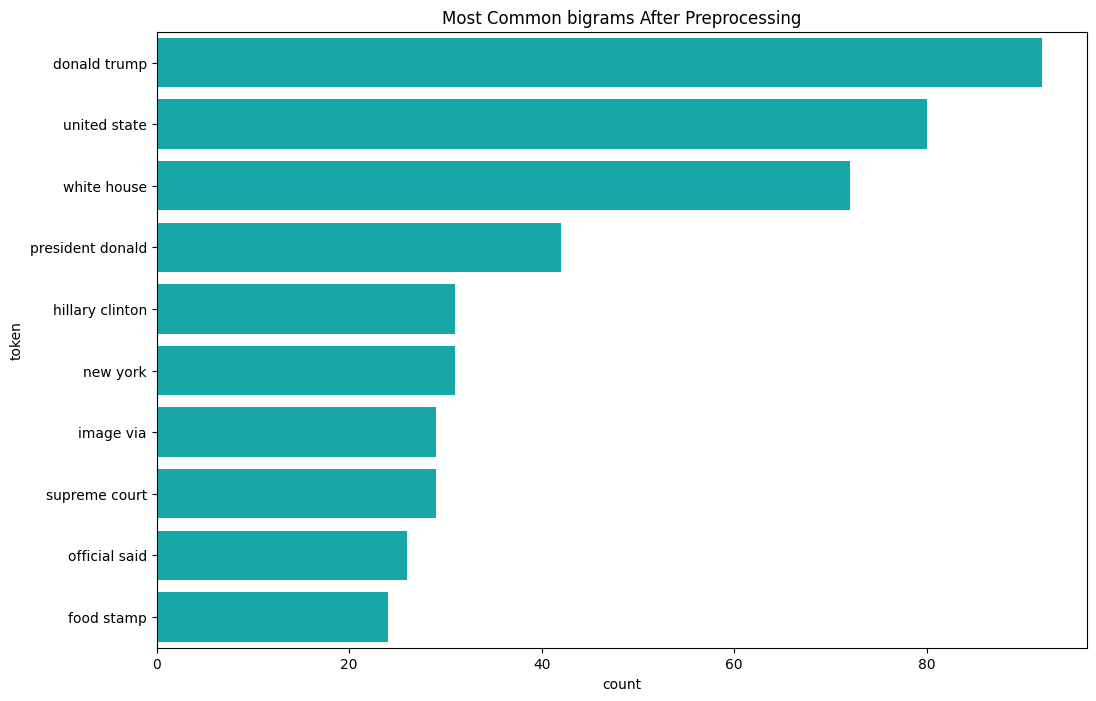

In [39]:
# bigramの可視化（全体）
bigrams['token'] = bigrams['index'].apply(lambda x: f"{x[0]} {x[1]}") 

sns.barplot(x = "count", 
            y = "token", 
            data=bigrams,
            orient = 'h',
            palette=[default_plot_colour],
            hue = "token", legend = False)\
.set(title='Most Common bigrams After Preprocessing')

In [40]:
#前処理後のbigram頻出度（fake）
tokens_clean_fake_2 = sum(data[data["fake_or_factual"] == "Fake News"]["text_clean"], [])
unigrams_fake_2 = pd.Series(nltk.ngrams(tokens_clean_fake_2, 2)).value_counts().reset_index()[:10]
unigrams_fake_2.columns = ["index", "count"]
print(unigrams_fake_2)

                index  count
0     (donald, trump)     42
1        (image, via)     29
2       (food, stamp)     24
3     (united, state)     24
4      (white, house)     24
5  (hillary, clinton)     21
6  (trump, supporter)     16
7         (new, york)     14
8  (president, obama)     11
9       (november, 8)     11


In [41]:
# 前処理後のngram頻出度（fact）
tokens_clean_fact_2 = sum(data[data["fake_or_factual"] == "Factual News"]["text_clean"], [])
unigrams_fact_2 = pd.Series(nltk.ngrams(tokens_clean_fact_2, 2)).value_counts().reset_index()[:10]
unigrams_fact_2.columns = ["index", "count"]
print(unigrams_fact_2)

                 index  count
0      (united, state)     56
1      (donald, trump)     50
2       (white, house)     48
3  (president, donald)     39
4     (official, said)     26
5     (told, reporter)     21
6  (attorney, general)     21
7    (said, statement)     20
8     (supreme, court)     19
9    (prime, minister)     19


### Sentiment Analysis

In [42]:
# vaderのSentiment Analysisi適用
vader_sentiment = SentimentIntensityAnalyzer()

data["vader_sentiment_score"] = data["text"].apply(lambda review: vader_sentiment.polarity_scores(review)["compound"])

In [43]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590


In [44]:
idx_neg = (data['vader_sentiment_score'] - (-1)).abs().idxmin()
print("=== -1 (最もネガティブ) に一番近い文章 ===")
print(f"Score: {data.loc[idx_neg, 'vader_sentiment_score']}")
print(data.loc[idx_neg, 'text'])

=== -1 (最もネガティブ) に一番近い文章 ===
Score: -0.9996
This guy just wants everyone dead.Pastor Steven Anderson of Faithful Word Baptist Church in Arizona just does not know how to shut his mouth.The day after the Orlando mass shooting, Anderson praised the 49 murders and called upon the government to execute all gay people across the nation.Just this past Sunday, Anderson repeated his call to execute gay people but added a call to purge any Christians who supports the LGBT community.And now Anderson is calling for reinstating the death penalty against anyone who is tried and convicted of committing adultery. Adultery is not a crime in the United States, but Anderson called for punishing those who commit it with death in a written manifesto on his blog last week. When someone says that homosexuality is worthy of death according to the Bible, people inevitably will bring up other sins that were also punishable by death in the Old Testament,  he wrote.  They think they are somehow catching us in hy

In [45]:
idx_neg = (data['vader_sentiment_score'] - 1).abs().idxmin()
print("=== 1 (最もポジティブ) に一番近い文章 ===")
print(f"Score: {data.loc[idx_neg, 'vader_sentiment_score']}")
print(data.loc[idx_neg, 'text'])

=== -1 (最もネガティブ) に一番近い文章 ===
Score: 0.9978
LONDON (Reuters) - Formula One’s new owners Liberty Media may have made a mistake  in ousting commercial supremo Bernie Ecclestone immediately after completing their takeover of the sport, according to former FIA president Max Mosley. Ecclestone, 86, was replaced by American Chase Carey on Jan. 23 as chief executive of Formula One and appointed ‘Emeritus Chairman’ - a position without a clearly defined role for the Briton. Liberty have, however, said they hope Ecclestone will continue to offer advice to the board. “If it had been me in the case of Liberty, I’d have kept Bernie on to do the things that he’s superbly good at - such as dealing with the promoters and the organizers and all that side of it,” Mosley told Reuters. The Briton, a close ally of Ecclestone while running the governing body, said Liberty could have concentrated on “doing the things that up to now have not been done” in Formula One such as virtual reality and digital techno

In [46]:
idx_neg = (data['vader_sentiment_score'] - 0).abs().idxmin()
print("=== 一番中立的な文章===")
print(f"Score: {data.loc[idx_neg, 'vader_sentiment_score']}")
print(data.loc[idx_neg, 'text'])

=== -1 (最もネガティブ) に一番近い文章 ===
Score: 0.0
THIS REMINDS ME OF WHEN HILLARY WAS CAMPAIGNING AND PULLED OUT THE ACCENT: 


<Axes: xlabel='vader_sentiment_label'>

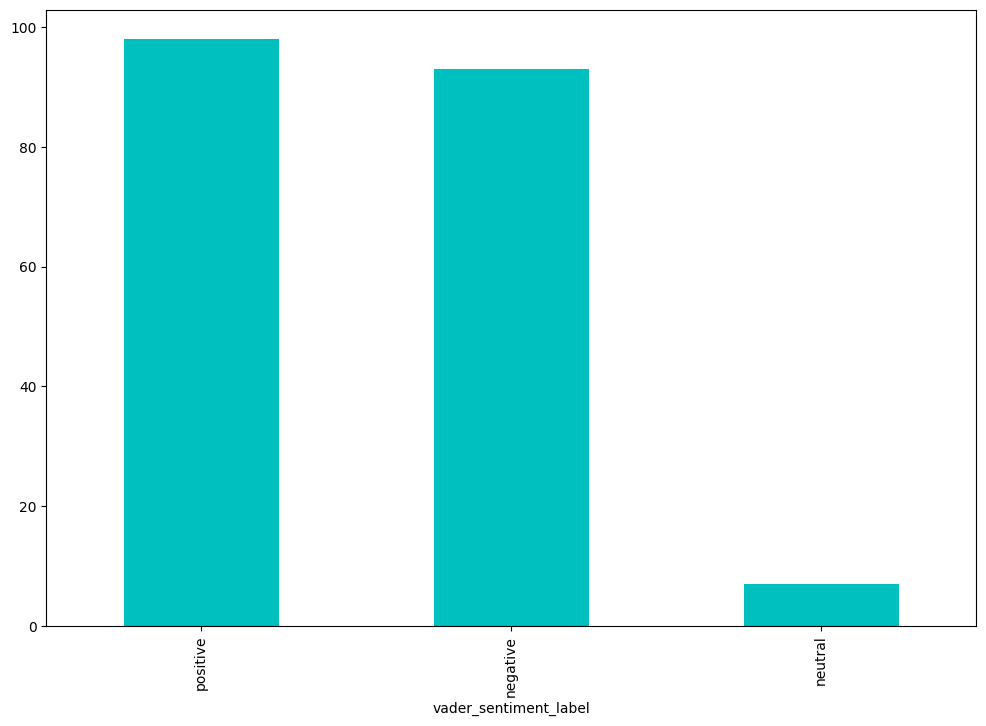

In [47]:
# vaderによる総合スコアの可視化
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/var/folders/_1/45kfssl94hl6vgk_4qg_qq5c0000gn/T/ipykernel_34439/1822099854.py:2: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

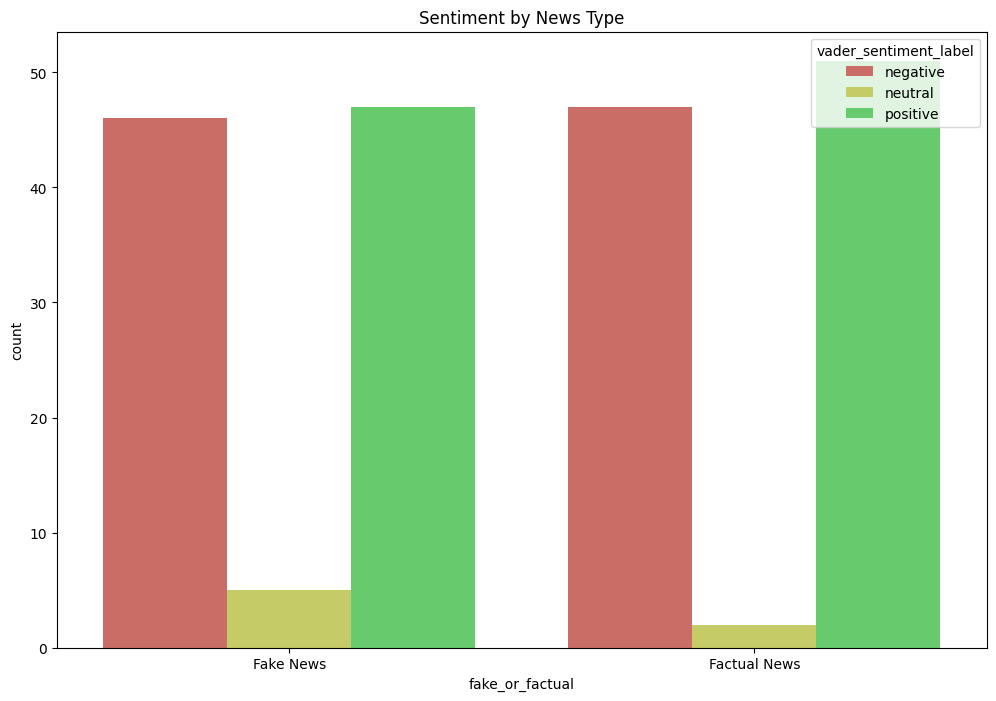

In [48]:
# FakeNewsとFactNewsそれぞれにおける割合
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette("hls"),
    data = data
) \
.set(title='Sentiment by News Type')

### LDA

In [49]:
# FakeNewsをBowでベクトル化
fake_news_text = data[data["fake_or_factual"] == "Fake News"]["text_clean"].reset_index(drop=True)
dictionary_fake = corpora.Dictionary(fake_news_text)
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

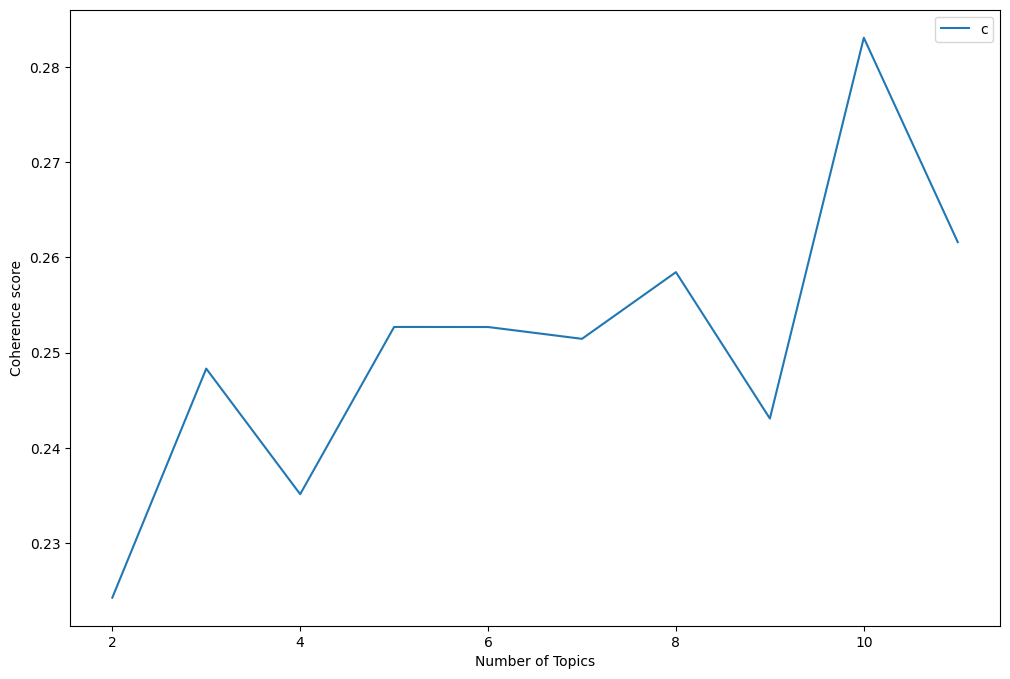

In [50]:
# coherence scoresにより、トピック数の検証
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=num_topics_i, id2word = dictionary_fake)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())
    
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [51]:
# トピック数8でLDAの作成
num_topics_fake = 8

lda_model_fake = gensim.models.LdaModel(corpus=doc_term_fake, 
                                 id2word=dictionary_fake,
                                 num_topics=num_topics_fake)

lda_model_fake.print_topics(num_topics=num_topics_fake, num_words=10)

[(0,
  '0.004*"republican" + 0.003*"stamp" + 0.003*"trump" + 0.003*"food" + 0.003*"year" + 0.003*"million" + 0.003*"said" + 0.002*"one" + 0.002*"also" + 0.002*"mccain"'),
 (1,
  '0.016*"trump" + 0.005*"u" + 0.005*"would" + 0.004*"mccain" + 0.004*"woman" + 0.003*"people" + 0.003*"one" + 0.003*"president" + 0.003*"time" + 0.003*"student"'),
 (2,
  '0.007*"trump" + 0.007*"clinton" + 0.005*"said" + 0.005*"president" + 0.004*"state" + 0.004*"would" + 0.003*"school" + 0.003*"time" + 0.003*"year" + 0.003*"law"'),
 (3,
  '0.008*"trump" + 0.006*"clinton" + 0.005*"woman" + 0.004*"president" + 0.004*"republican" + 0.004*"party" + 0.004*"time" + 0.003*"one" + 0.003*"state" + 0.003*"campaign"'),
 (4,
  '0.006*"trump" + 0.006*"would" + 0.004*"said" + 0.004*"state" + 0.004*"one" + 0.004*"president" + 0.003*"time" + 0.003*"know" + 0.003*"go" + 0.002*"year"'),
 (5,
  '0.006*"trump" + 0.005*"republican" + 0.005*"state" + 0.004*"clinton" + 0.004*"said" + 0.004*"president" + 0.003*"one" + 0.003*"people" +

### TF-IDF & LSA(TF-IDFとLSAで特徴量の質の変化)

In [52]:
# TF-IDF
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus=doc_term_fake, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf
    

In [53]:
# TF-IDF後のデータでのcoherence　scoresの大枠

def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    coherence_values = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())
    # plot 
    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()

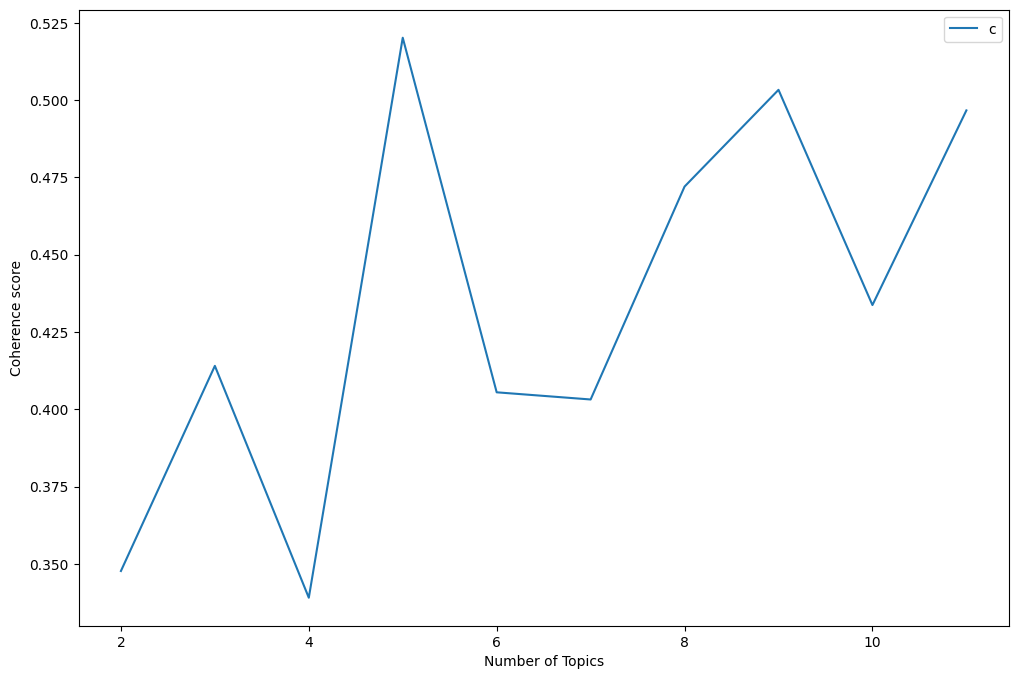

In [54]:
# 適用
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [55]:
# トピック数５のトークン確認
lsa_fake = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=5)
lsa_fake.print_topics()

[(0,
  '0.218*"trump" + 0.135*"clinton" + 0.094*"woman" + 0.087*"president" + 0.086*"republican" + 0.085*"obama" + 0.084*"party" + 0.083*"school" + 0.081*"said" + 0.079*"time"'),
 (1,
  '0.299*"boiler" + 0.253*"room" + 0.250*"acr" + 0.186*"jay" + 0.185*"animal" + 0.176*"episode" + 0.147*"analysis" + 0.122*"dyer" + 0.119*"savant" + 0.119*"moralist"'),
 (2,
  '-0.219*"school" + 0.195*"clinton" + 0.163*"conference" + -0.151*"county" + -0.137*"student" + 0.120*"press" + 0.116*"trump" + 0.112*"hillary" + -0.101*"love" + 0.095*"email"'),
 (3,
  '0.375*"flynn" + 0.151*"russian" + 0.111*"email" + 0.109*"30" + 0.101*"department" + 0.100*"information" + 0.100*"nana" + 0.099*"official" + 0.098*"mccain" + -0.096*"trump"'),
 (4,
  '-0.235*"trump" + -0.223*"flynn" + -0.166*"conference" + 0.165*"clinton" + 0.153*"dnc" + 0.151*"sander" + 0.127*"email" + -0.111*"press" + 0.109*"rich" + -0.084*"tax"')]

In [56]:
"""=====(fact)====="""

'=====(fact)====='

In [57]:
# FactNewsについてもLSIでトピックを作れるか検証
fact_news_text = data[data["fake_or_factual"] == "Factual News"]["text_clean"].reset_index(drop=True)
dictionary_fact = corpora.Dictionary(fact_news_text)
doc_term_fact = [dictionary_fact.doc2bow(text) for text in fake_news_text]

In [58]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus=doc_term_fact, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf

In [59]:
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    coherence_values = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())
    # plot 
    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()

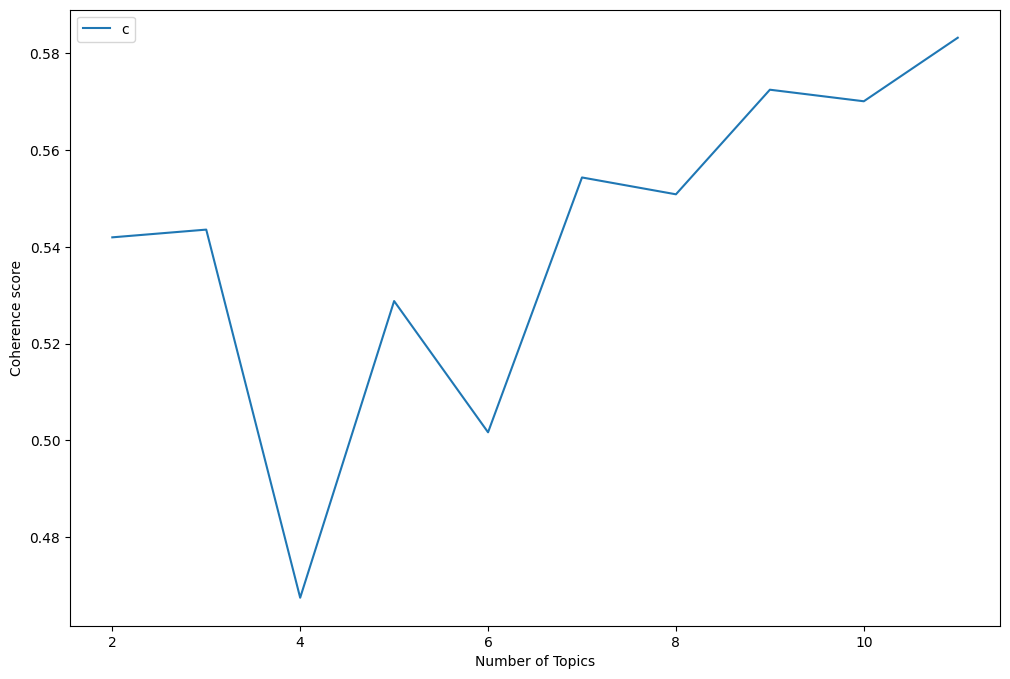

In [60]:
corpus_tfidf_fact = tfidf_corpus(doc_term_fact)
get_coherence_scores(corpus_tfidf_fact, dictionary_fact, fact_news_text, min_topics=2, max_topics=11)

In [61]:
# トピック数のトークン確認
lsa_fact = LsiModel(corpus_tfidf_fact, id2word=dictionary_fact, num_topics=5)
lsa_fact.print_topics()

[(0,
  '0.236*"trump" + 0.159*"clinton" + 0.115*"woman" + 0.096*"republican" + 0.095*"school" + 0.094*"party" + 0.093*"president" + 0.093*"hillary" + 0.090*"time" + 0.089*"said"'),
 (1,
  '0.413*"room" + 0.299*"jay" + 0.241*"analysis" + 0.174*"page" + 0.171*"link" + 0.169*"otherwise" + 0.168*"host" + 0.164*"political" + 0.149*"street" + 0.142*"program"'),
 (2,
  '0.287*"clinton" + -0.263*"school" + 0.208*"hillary" + 0.180*"september" + 0.158*"2016" + -0.152*"student" + 0.122*"campaigning" + -0.112*"love" + 0.109*"debate" + 0.108*"21"'),
 (3,
  '0.202*"november" + 0.185*"trump" + 0.175*"school" + 0.171*"vote" + 0.171*"8" + -0.171*"russian" + -0.160*"email" + 0.153*"student" + 0.149*"2016" + 0.139*"supporter"'),
 (4,
  '-0.290*"trump" + 0.257*"september" + 0.203*"2016" + 0.199*"clinton" + -0.187*"conference" + 0.175*"21" + 0.148*"hillary" + 0.123*"law" + -0.115*"donald" + -0.113*"press"')]

### モデルの作成

In [62]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [63]:
X = [" ".join(map(str, x)) for x in data["text_clean"]]
Y = data["fake_or_factual"]

In [64]:
# CountVectorizerの適用
countvec = CountVectorizer()
countvec_fit = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=countvec.get_feature_names_out())

In [65]:
# データの訓練用とテスト用に分割
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size=0.3)

In [66]:
# ロジスティック回帰
lr = LogisticRegression(random_state=0).fit(X_train, y_train)

In [67]:
y_pred_lr = lr.predict(X_test)

In [68]:
accuracy_score(y_pred_lr, y_test)

0.9333333333333333

In [69]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

Factual News       0.96      0.90      0.93        29
   Fake News       0.91      0.97      0.94        31

    accuracy                           0.93        60
   macro avg       0.94      0.93      0.93        60
weighted avg       0.94      0.93      0.93        60



In [70]:
# linearSVM
svm = SGDClassifier().fit(X_train, y_train)

In [71]:
y_pred_svm = svm.predict(X_test)

In [72]:
accuracy_score(y_pred_svm, y_test)

0.8

In [73]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

Factual News       0.77      0.83      0.80        29
   Fake News       0.83      0.77      0.80        31

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



In [74]:
#正解のラベル付け
le = LabelEncoder()
y_encoded = le.fit_transform(Y)

In [75]:
vader_score = data[['vader_sentiment_score']].reset_index(drop=True)
X_combined = pd.concat([bag_of_words, vader_score], axis=1)

In [76]:
X_train_va, X_test_va, y_train_va, y_test_va = train_test_split(X_combined, y_encoded, test_size=0.3, random_state=0)

In [77]:
model_xgb = xgb.XGBClassifier(
    max_depth=4,           # データサイズに合わせて過学習を防ぐために浅めに設定
    learning_rate=0.1, 
    n_estimators=100, 
    random_state=0,
    eval_metric='logloss'
)
model_xgb.fit(X_train_va, y_train_va)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [78]:
y_pred_xgb = model_xgb.predict(X_test_va)

In [79]:
accuracy_score(y_pred_xgb, y_test_va)

0.9

In [80]:
print(classification_report(y_test_va, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        34
           1       0.86      0.92      0.89        26

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60



In [92]:
# 決定木
model_dtc = DecisionTreeClassifier(max_depth=5, random_state=0)
model_dtc.fit(X_train, y_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current nod

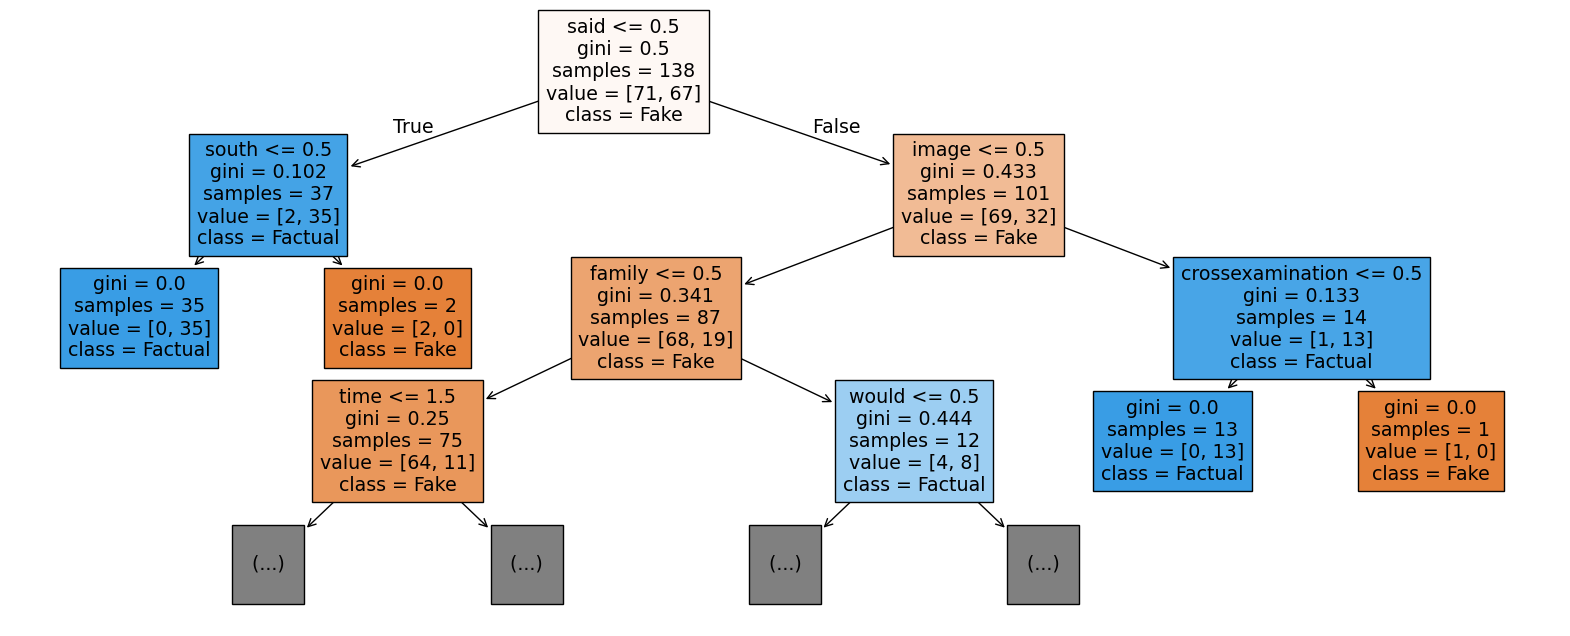

In [93]:
# 木構造を可視化
plt.figure(figsize=(20, 8))
plot_tree(model_dtc, feature_names=countvec.get_feature_names_out(),
          class_names=['Fake', 'Factual'], filled=True, max_depth=3)
plt.show()

In [94]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

# クラスごとの単語の対数確率
log_prob_df = pd.DataFrame(
    nb.feature_log_prob_.T,
    index=countvec.get_feature_names_out(),
    columns=['Fake', 'Factual']
)
# Fakeに特徴的な単語（確率差が大きい順）
log_prob_df['diff'] = log_prob_df['Fake'] - log_prob_df['Factual']
print(log_prob_df.sort_values('diff', ascending=False).head(10))


                   Fake   Factual      diff
myanmar       -6.976475 -9.962039  2.985564
startup       -7.177146 -9.962039  2.784893
ban           -7.177146 -9.962039  2.784893
amendment     -7.177146 -9.962039  2.784893
expensing     -7.177146 -9.962039  2.784893
environmental -7.294929 -9.962039  2.667110
prime         -7.359468 -9.962039  2.602572
warren        -7.359468 -9.962039  2.602572
britain       -7.359468 -9.962039  2.602572
supreme       -7.428461 -9.962039  2.533579
